In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from matplotlib.pyplot import rc_context
from PIL import Image
import pegasus as pg
import pegasusio as io
import pegasusio
from pegasusio import UnimodalData, MultimodalData
import scipy.stats as st
import squidpy as sq
import seaborn as sns
import os
import glob
from utils.lists import *
from utils.plot_utils import *
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
import spatialdata_io
import spatialdata as sd
import warnings
warnings.filterwarnings('ignore')
import spatialdata_plot
from spatialdata import bounding_box_query
import czifile
from skimage import io

from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import matplotlib.patches as patches

2025-04-12 12:36:47.970555: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-04-12 12:36:48.297740: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-12 12:36:48.368847: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-04-12 12:36:48.368875: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore 

# ED Fig. 5a QC plots

In [3]:
data = sc.read_h5ad('/home/ah2428/girgenti/ah2428/xenium/data_processed_resegment/snXenium.h5ad')

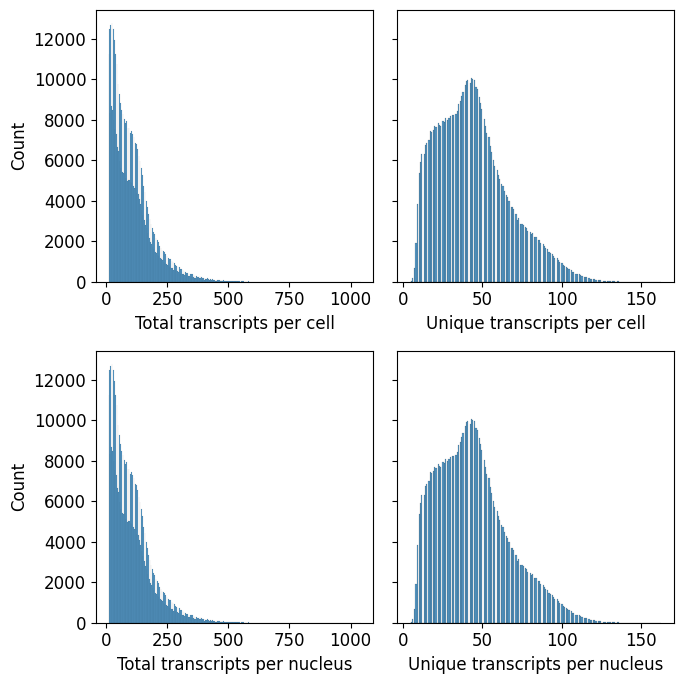

In [4]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['font.size']='12'

fig, ax = plt.subplots(2, 2, figsize=(7,7),sharey=True)
ax = ax.flatten()

sns.histplot(
    data.obs["total_counts"],
    kde=False,
    ax=ax[0],
)
ax[0].set_xlabel('Total transcripts per cell')

sns.histplot(
    data.obs["n_genes_by_counts"],
    kde=False,
    ax=ax[1],
)
ax[1].set_xlabel('Unique transcripts per cell')

sns.histplot(
    data.obs["total_counts"],
    kde=False,
    ax=ax[2]
)
ax[2].set_xlabel('Total transcripts per nucleus')

sns.histplot(
    data.obs["n_genes_by_counts"],
    kde=False,
    ax=ax[3],
)
ax[3].set_xlabel('Unique transcripts per nucleus')

fig.tight_layout()
plt.savefig('/home/ah2428/palmer_scratch/figs/ed5/QC.pdf',bbox_inches='tight',dpi=300)

# ED Fig. 5b Neighborhood enrichment

  0%|          | 0/1000 [00:00<?, ?/s]

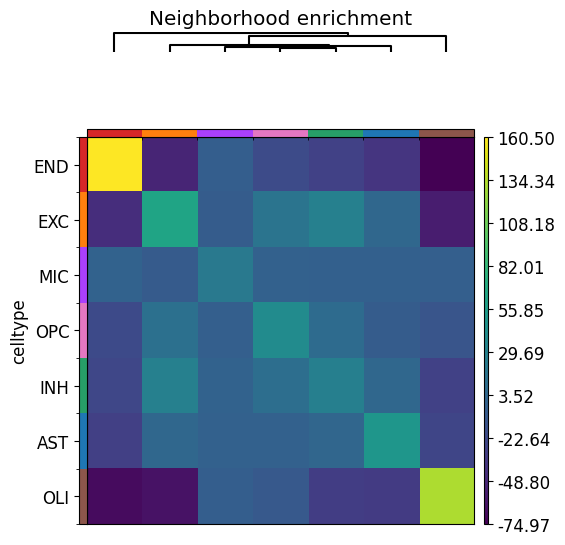

In [5]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
sq.gr.spatial_neighbors(data)
sq.gr.nhood_enrichment(data, cluster_key="celltype")
sq.pl.nhood_enrichment(data, cluster_key="celltype", method="average", figsize=(5,5))
plt.savefig('/home/ah2428/palmer_scratch/figs/ed5/neighbor.pdf',bbox_inches='tight',dpi=300)

# ED Fig. 5c CON and PTSD slide Cell types and H&E

INFO     reading /gpfs/gibbs/pi/girgenti/ah2428/xenium/data/5638_resegment/outs/cell_feature_matrix.h5             


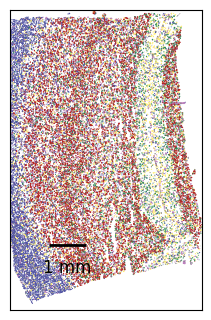

In [4]:
brnum = '5638'
#brnum = '5173'
sdata = get_xenium_sdata(brnum)

fig = sdata.pl.render_shapes("cell_boundaries",
                       color='celltype',
                       groups=['EXC','INH','OLI','OPC','END','AST','MIC'],
                       palette=['#b22222', '#2E8B57', '#5254a3', '#aec7e8', '#bc80bd', '#ffed6f', '#7f7f7f'],
                       scale=5, outline=False).pl.show(figsize=(2,4),return_ax=True)


ax = fig
fontprops = fm.FontProperties(size=12)
scalebar = AnchoredSizeBar(ax.transData,
                           size=1000/0.2125,        # adjust to your units; e.g., x pixels = 1 mm 
                           label='1 mm',
                           loc='lower left',
                           pad=1,
                           borderpad=1,
                           sep=10,
                           frameon=False,
                           color='black',
                           fontproperties=fontprops)
scalebar.size_bar.get_children()[0].set_linewidth(2)
ax.add_artist(scalebar)

ax.set_ylim(42000,3000)
#ax.set_ylim(37457,1500)

plt.legend('', frameon=False)
plt.title('')
plt.xticks([])
plt.yticks([])

plt.savefig('/home/ah2428/palmer_scratch/figs/xenium/ED_fig_5c_con.pdf',bbox_inches='tight',dpi=300)

In [10]:
sdata = spatialdata_io.xenium(f'/gpfs/gibbs/pi/girgenti/ah2428/xenium/data/5638_resegment/outs/')

INFO     reading /gpfs/gibbs/pi/girgenti/ah2428/xenium/data/5638_resegment/outs/cell_feature_matrix.h5             


In [12]:
sdata

SpatialData object with:
├── Images
│     ├── 'morphology_focus': MultiscaleSpatialImage[cyx] (1, 44227, 25627), (1, 22113, 12813), (1, 11056, 6406), (1, 5528, 3203), (1, 2764, 1601)
│     └── 'morphology_mip': MultiscaleSpatialImage[cyx] (1, 44227, 25627), (1, 22113, 12813), (1, 11056, 6406), (1, 5528, 3203), (1, 2764, 1601)
├── Labels
│     ├── 'cell_labels': MultiscaleSpatialImage[yx] (44227, 25627), (22113, 12813), (11056, 6406), (5528, 3203), (2764, 1601)
│     └── 'nucleus_labels': MultiscaleSpatialImage[yx] (44227, 25627), (22113, 12813), (11056, 6406), (5528, 3203), (2764, 1601)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 10) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (42782, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (42782, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (42782, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (42782, 366)
with coordinate systems:
▸ 'global', with 

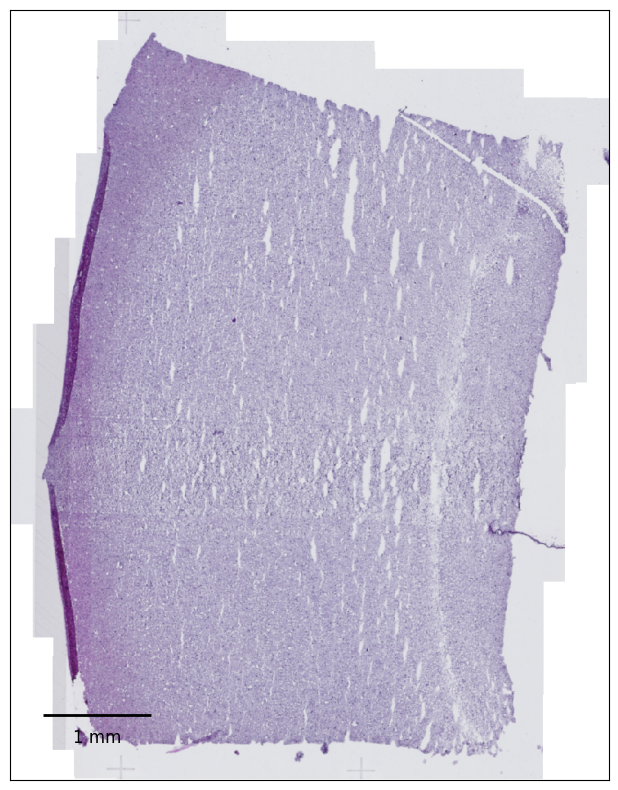

In [25]:
img = czifile.imread("/home/ah2428/girgenti/ah2428/xenium/histology/5638_dlpfc_XeniumH&E20x.czi")
img_flipped = img.transpose(1, 0, 2)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img_flipped)

# Add scalebar
fontprops = fm.FontProperties(size=12)
scalebar = AnchoredSizeBar(ax.transData,
                           size=1000 / 6.8,  # 1 mm in pixels
                           label='1 mm',
                           loc='lower left',
                           pad=1,
                           borderpad=1,
                           sep=10,
                           frameon=False,
                           color='black',
                           fontproperties=fontprops)

# Thicken the scalebar line
scalebar.size_bar.get_children()[0].set_linewidth(2)

# Add to plot
ax.add_artist(scalebar)

plt.xticks([])
plt.yticks([])

plt.savefig('/home/ah2428/palmer_scratch/figs/xenium/ED_fig_5c_CON_h&e.pdf',bbox_inches='tight',dpi=300)

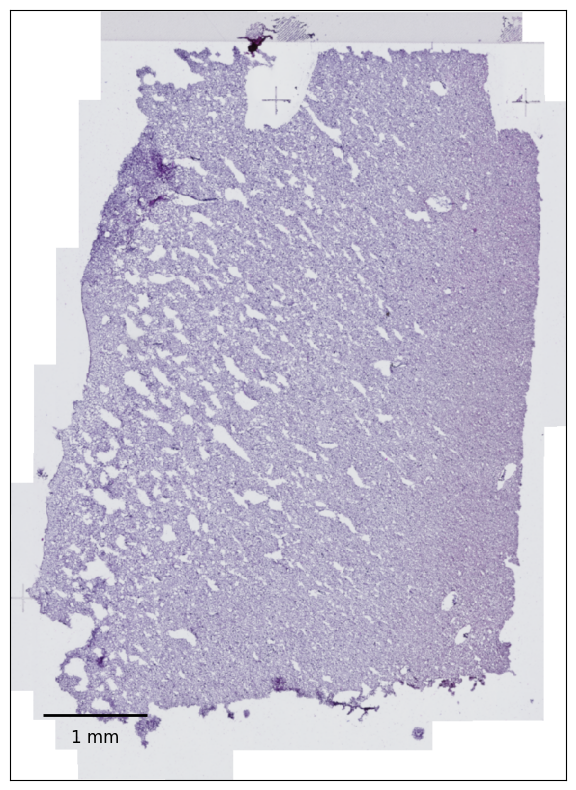

In [26]:
img = czifile.imread("/home/ah2428/girgenti/ah2428/xenium/histology/5173_dlpfc_XeniumH&E20x.czi")
img_flipped = img.transpose(1, 0, 2)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img_flipped)

# Add scalebar
fontprops = fm.FontProperties(size=12)
scalebar = AnchoredSizeBar(ax.transData,
                           size=1000 / 6.8,  # 1 mm in pixels
                           label='1 mm',
                           loc='lower left',
                           pad=1,
                           borderpad=1,
                           sep=10,
                           frameon=False,
                           color='black',
                           fontproperties=fontprops)

# Thicken the scalebar line
scalebar.size_bar.get_children()[0].set_linewidth(2)

# Add to plot
ax.add_artist(scalebar)

plt.xticks([])
plt.yticks([])
plt.savefig('/home/ah2428/palmer_scratch/figs/xenium/ED_fig_5c_PTSD_h&e.pdf',bbox_inches='tight',dpi=300)

# ED Fig. 5d snXenium vs snRNA log2FC correlation 

In [16]:
xenium_genes = pd.read_csv('/home/ah2428/palmer_scratch/PTSD/xenium/xenium_genes.csv',header=None)[0].values

In [24]:
xenium_ups_n = []
xenium_downs_n = []
xenium_ups = []
xenium_downs = []

#mast = pd.read_csv(f'/home/ah2428/ShareZhangLab/PTSD/RNA/DEG_results_df/snXenium/PTSD_vs_CON/MAST_DEG.csv',sep='\t')
mast = pd.read_csv(f'/home/ah2428/ShareZhangLab/PTSD/RNA/DEG_results_df/scXenium/PTSD_vs_CON/MAST_DEG.csv',sep='\t')

for celltype in ['EXC','INH','OLI','OPC','END','AST','MIC']:
    mast_celltype = mast[mast.Celltype==celltype]
    mast_up = mast_celltype[mast_celltype.log2FC > np.log2(1.1)][mast_celltype.FDR < 0.01].Genename.values
    mast_down = mast_celltype[mast_celltype.log2FC < -np.log2(1.1)][mast_celltype.FDR < 0.01].Genename.values
    
    xenium_ups_n.append(len(mast_up))
    xenium_downs_n.append(len(mast_down))
    xenium_ups.append(mast_up)
    xenium_downs.append(mast_down)

In [25]:
rna_ups_n = []
rna_downs_n = []
rna_ups = []
rna_downs = []

mast = pd.read_csv(f'/home/ah2428/ShareZhangLab/PTSD/RNA/DEG_results_df/snRNA/PTSD_vs_CON/MAST_DEG.csv',sep='\t')

for celltype in ['EXC','INH','OLI','OPC','END','AST','MIC']:
    mast_celltype = mast[mast.Celltype==celltype]
    mast_up = mast_celltype[mast_celltype.log2FC > np.log2(1.2)][mast_celltype.FDR < 0.01].Genename.values
    mast_down = mast_celltype[mast_celltype.log2FC < -np.log2(1.2)][mast_celltype.FDR < 0.01].Genename.values

    inter_up = list(set(mast_up) & set(xenium_genes))
    inter_down = list(set(mast_down) & set(xenium_genes))
    rna_ups.append(inter_up)
    rna_downs.append(inter_down)
    rna_ups_n.append(len(inter_up))
    rna_downs_n.append(len(inter_down))

In [26]:
inter_up_genes = []
for i,celltype in enumerate(['EXN','IN','OLG','OPC','END','AST','MG']):
    rna_up = rna_ups[i]
    xenium_up = xenium_ups[i]
    overlap = len(list(set(rna_up) & set(xenium_up)))
    inter_up_genes.append(list(set(rna_up) & set(xenium_up)))

In [27]:
inter_down_genes = []
for i,celltype in enumerate(['EXC','INH','OLI','OPC','END','AST','MIC']):
    rna_down = rna_downs[i]
    xenium_down = xenium_downs[i]
    overlap = len(list(set(rna_down) & set(xenium_down)))
    inter_down_genes.append(list(set(rna_down) & set(xenium_down)))

In [28]:
rna_mast = pd.read_csv('/home/ah2428/ShareZhangLab/PTSD/RNA/DEG_results_df/snRNA/PTSD_vs_CON/MAST_DEG.csv',sep='\t')
#xenium_mast = pd.read_csv('/home/ah2428/ShareZhangLab/PTSD/RNA/DEG_results_df/snXenium/PTSD_vs_CON/MAST_DEG.csv',sep='\t')
xenium_mast = pd.read_csv('/home/ah2428/ShareZhangLab/PTSD/RNA/DEG_results_df/scXenium/PTSD_vs_CON/MAST_DEG.csv',sep='\t')

In [29]:
rna_fcs = []
xenium_fcs = []
for ii,celltype in enumerate(['EXC','INH','OLI','OPC','END','AST','MIC']):
    genes_up = inter_up_genes[ii]
    genes_down = inter_down_genes[ii]
    rna_celltype = rna_mast[rna_mast.Celltype==celltype]
    xenium_celltype = xenium_mast[xenium_mast.Celltype==celltype]
    if len(genes_up) >= 1:
        for g in genes_up:
            rna_fc = rna_celltype[rna_celltype.Genename==g].log2FC.values[0]
            xenium_fc = xenium_celltype[xenium_celltype.Genename==g].log2FC.values[0]
            rna_fcs.append(rna_fc)
            xenium_fcs.append(xenium_fc)
    else:
        pass
    if len(genes_down) >= 1:
        for j in genes_down:
            rna_fc = rna_celltype[rna_celltype.Genename==j].log2FC.values[0]
            xenium_fc = xenium_celltype[xenium_celltype.Genename==j].log2FC.values[0]
            rna_fcs.append(rna_fc)
            xenium_fcs.append(xenium_fc)
    else:
        pass

Text(0, 0.5, 'snRNA log2FC')

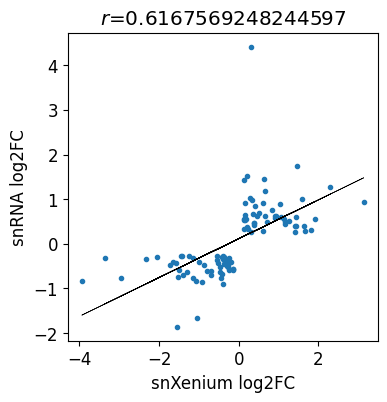

In [23]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
fig, ax = plt.subplots(figsize=(4,4))
x = xenium_fcs
y = rna_fcs
y = np.array(y)
x = np.array(x)

ax.plot(x,y,'.')
r = np.corrcoef(x,y)[0][1]
m, b = np.polyfit(x,y,1)
ax.plot(x, m*x+b, color='k',linewidth=0.5)
ax.set_title(f'$r$={r}')
ax.set_xlabel('snXenium log2FC')
ax.set_ylabel('snRNA log2FC')

# ED Fig. 5d scXenium vs snRNA log2FC correlation 

Text(0, 0.5, 'snRNA log2FC')

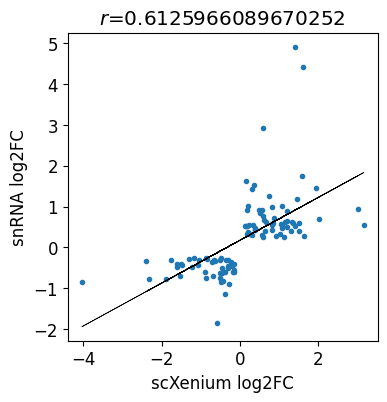

In [30]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
fig, ax = plt.subplots(figsize=(4,4))
x = xenium_fcs
y = rna_fcs
y = np.array(y)
x = np.array(x)

ax.plot(x,y,'.')
r = np.corrcoef(x,y)[0][1]
m, b = np.polyfit(x,y,1)
ax.plot(x, m*x+b, color='k',linewidth=0.5)
ax.set_title(f'$r$={r}')
ax.set_xlabel('scXenium log2FC')
ax.set_ylabel('snRNA log2FC')

# ED Fig. 5f snXenium IN PTSD vs CON MAST DEG Volcano plot

(-5.0, 5.0)

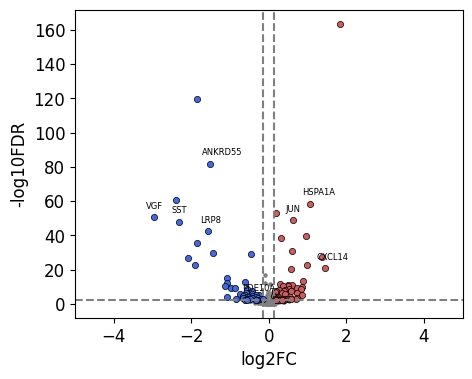

In [34]:
rna = pd.read_csv('/home/ah2428/ShareZhangLab/PTSD/RNA/DEG_results_df/snRNA/PTSD_vs_CON/MAST_DEG.csv',sep='\t')
rna = rna[rna.Celltype=='INH']
rna = rna[np.abs(rna.log2FC) > np.log2(1.2)][rna.FDR < 0.01]

rna_down = list(set(xenium_genes) & set(rna[rna.log2FC < 0].Genename.unique()))
rna_up = list(set(xenium_genes) & set(rna[rna.log2FC > 0].Genename.unique()))

deg = pd.read_csv('/home/ah2428/ShareZhangLab/PTSD/RNA/DEG_results_df/snXenium/PTSD_vs_CON/MAST_DEG.csv',sep='\t')

deg = deg[deg.Celltype=='INH']

deg.sort_values('FDR')

plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
fig, ax = plt.subplots(figsize=(5,4))
plt.scatter(x=deg.log2FC,y=deg.FDR.apply(lambda x:-np.log10(x)),s=5,label="Not significant",color='gray')

# highlight down- or up- regulated genes
down = deg[(deg.log2FC < -np.log2(1.1))&(deg.FDR < 0.01)]
up = deg[(deg.log2FC > np.log2(1.1))&(deg.FDR < 0.01)]

plt.scatter(x=down['log2FC'],y=down['FDR'].apply(lambda x:-np.log10(x)),s=20,color='royalblue',edgecolor='black',linewidth=0.5)
plt.scatter(x=up['log2FC'],y=up['FDR'].apply(lambda x:-np.log10(x)),s=20,color='indianred',edgecolor='k',linewidth=0.5)
ups = []
for i in up.Genename.values:
    if i in rna_up:
        ups.append(i)
        x = up[up.Genename==i]
        plt.text(x.log2FC-0.2,-np.log10(x['FDR'])+5,i,fontsize=6)
downs = []
for i in down.Genename.values:
    if i in rna_down:
        downs.append(i)
        x = down[down.Genename==i]
        plt.text(x.log2FC-0.2,-np.log10(x['FDR'])+5,i,fontsize=6)

plt.xlabel("log2FC")
plt.ylabel("-log10FDR")
plt.axvline(-np.log2(1.1),color="grey",linestyle="--")
plt.axvline(np.log2(1.1),color="grey",linestyle="--")
plt.axhline(-np.log10(0.01),color="grey",linestyle="--")
plt.xlim([-5,5])

# ED Fig. 5g CXCL14 PTSD vs CON expression

2024-09-14 19:16:59,386 - pegasus.tools.preprocessing - INFO - Function 'log_norm' finished in 0.12s.


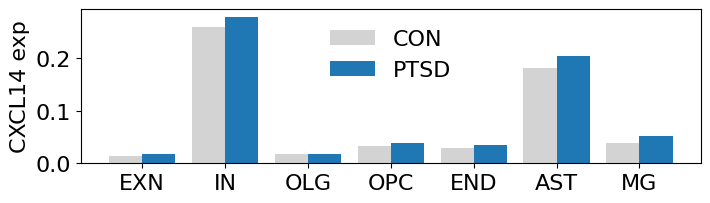

In [37]:
plot_xenium_gene_exp_barplot('CXCL14')

# ED Fig. 5h CXCL14 CON Xenium Slide 

INFO     reading /gpfs/gibbs/pi/girgenti/ah2428/xenium/data/5638_resegment/outs/cell_feature_matrix.h5             


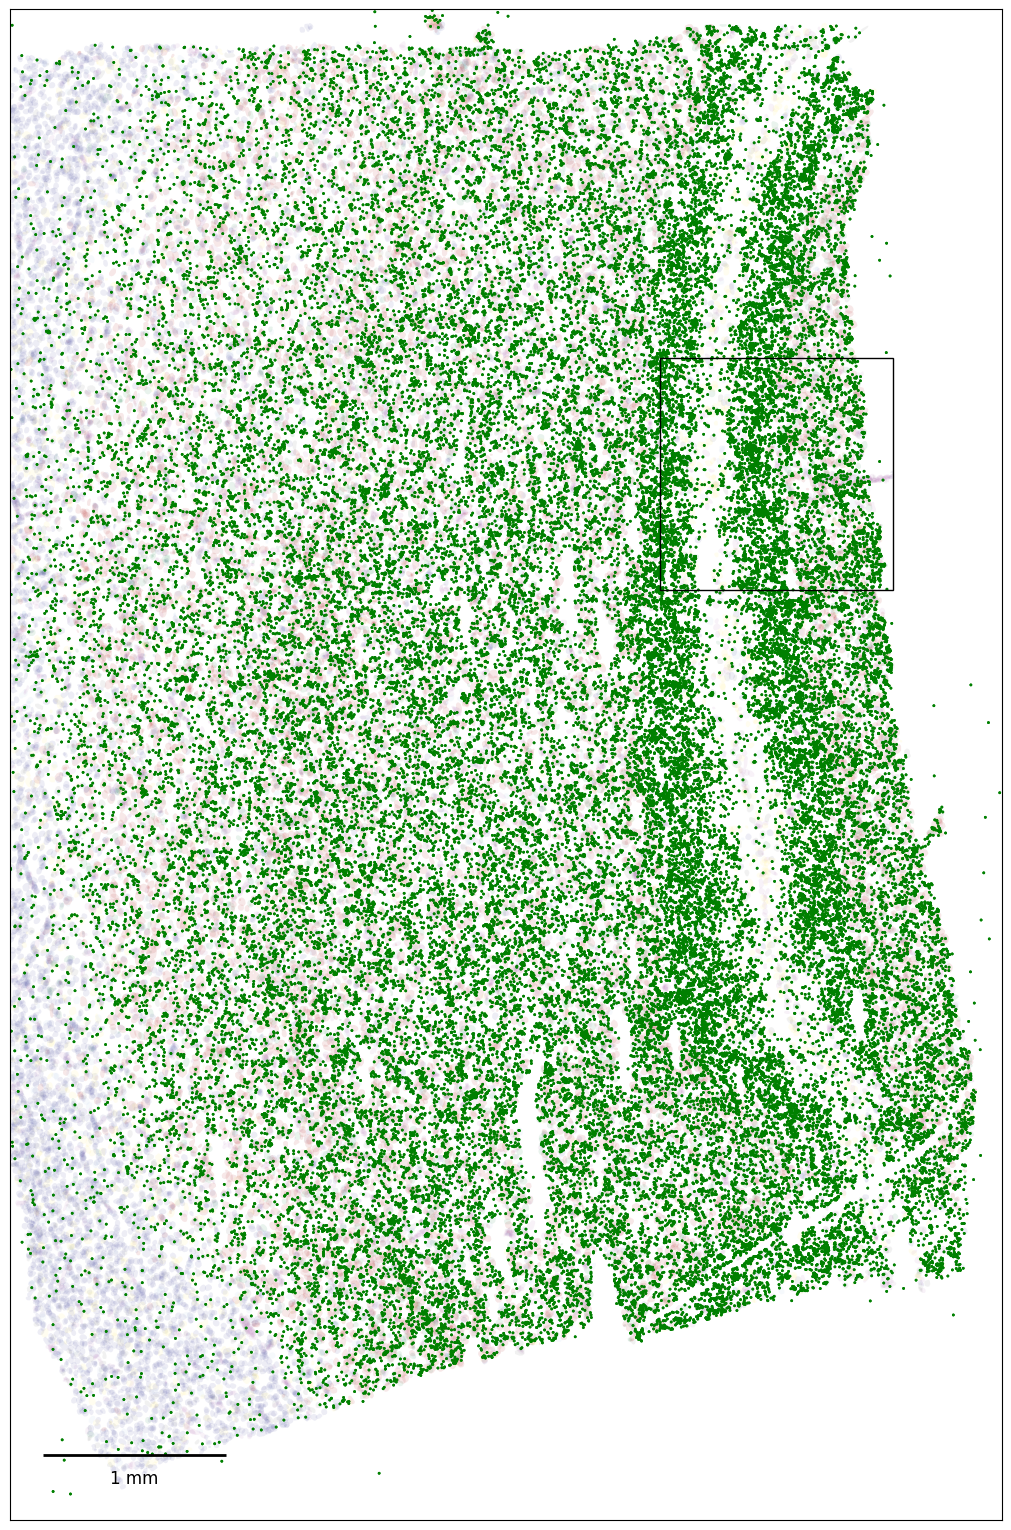

In [5]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

brnum = '5638'
gene = 'CXCL14'
color = 'green'

sdata = get_xenium_sdata(brnum)

fig = sdata.pl.render_shapes("cell_boundaries",
                             color='celltype',
                             groups=['EXC','INH','OLI','OPC','END','AST','MIC'],
                             palette=['#b22222', '#2E8B57', '#5254a3', '#aec7e8', '#bc80bd', '#ffed6f', '#7f7f7f'],
                             scale=5, 
                             outline=False, 
                             fill_alpha=0.1).pl.render_points('transcripts',
                                                              color='feature_name',
                                                              groups=gene,
                                                              palette=color,
                                                              size=1).pl.show(figsize=(10, 20), return_ax=True)

ax = fig
fontprops = fm.FontProperties(size=12)
scalebar = AnchoredSizeBar(ax.transData,
                           size=1000/0.2125,        # x pixels = 1 mm 
                           label='1 mm',
                           loc='lower left',
                           pad=1,
                           borderpad=1,
                           sep=10,
                           frameon=False,
                           color='black',
                           fontproperties=fontprops)
scalebar.size_bar.get_children()[0].set_linewidth(2)
ax.add_artist(scalebar)

rect = patches.Rectangle((16800, 12000), 6000, 6000,  # x, y, width, height
                         linewidth=1,
                         edgecolor='black',
                         facecolor='none')
ax.add_patch(rect)

ax.set_ylim(42000,3000)

plt.legend('', frameon=False)
plt.title('')
plt.xticks([])
plt.yticks([])

plt.savefig('/home/ah2428/palmer_scratch/figs/xenium/ED_fig_5h_con.pdf',bbox_inches='tight',dpi=300)

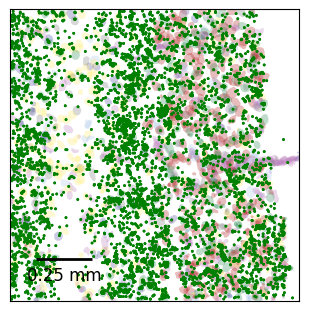

In [6]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

crop0 = lambda x: bounding_box_query(
    x,
    min_coordinate=[16800,12000],
    max_coordinate=[22800,18000],
    axes=("x", "y"),
    target_coordinate_system="global",
)
subset = crop0(sdata)

fig = subset.pl.render_shapes("cell_boundaries",
                       color='celltype',
                       groups=['EXC','INH','OLI','OPC','END','AST','MIC'],
                       palette=['#b22222','#2E8B57','#5254a3','#aec7e8','#bc80bd','#ffed6f','#7f7f7f'],
                       scale=5, 
                       outline=False, 
                       fill_alpha=0.3).pl.render_points('transcripts',color='feature_name',groups=gene,palette=color,size=1).pl.show(figsize=(3,3),return_ax=True)

ax = fig
fontprops = fm.FontProperties(size=12)
scalebar = AnchoredSizeBar(ax.transData,
                           size=250/0.2125,        # x pixels = 1 mm 
                           label='0.25 mm',
                           loc='lower left',
                           pad=0.5,
                           borderpad=0.5,
                           sep=5,
                           frameon=False,
                           color='black',
                           fontproperties=fontprops)
scalebar.size_bar.get_children()[0].set_linewidth(2)
ax.add_artist(scalebar)

plt.legend('',frameon=False)
plt.title('')
plt.xticks([])
plt.yticks([])
plt.savefig('/home/ah2428/palmer_scratch/figs/xenium/ED_fig_5h_con_inset.pdf',bbox_inches='tight',dpi=300)

# ED Fig. 5i CXCL14 PTSD Xenium Slide

INFO     reading /gpfs/gibbs/pi/girgenti/ah2428/xenium/data/5173_resegment/outs/cell_feature_matrix.h5             


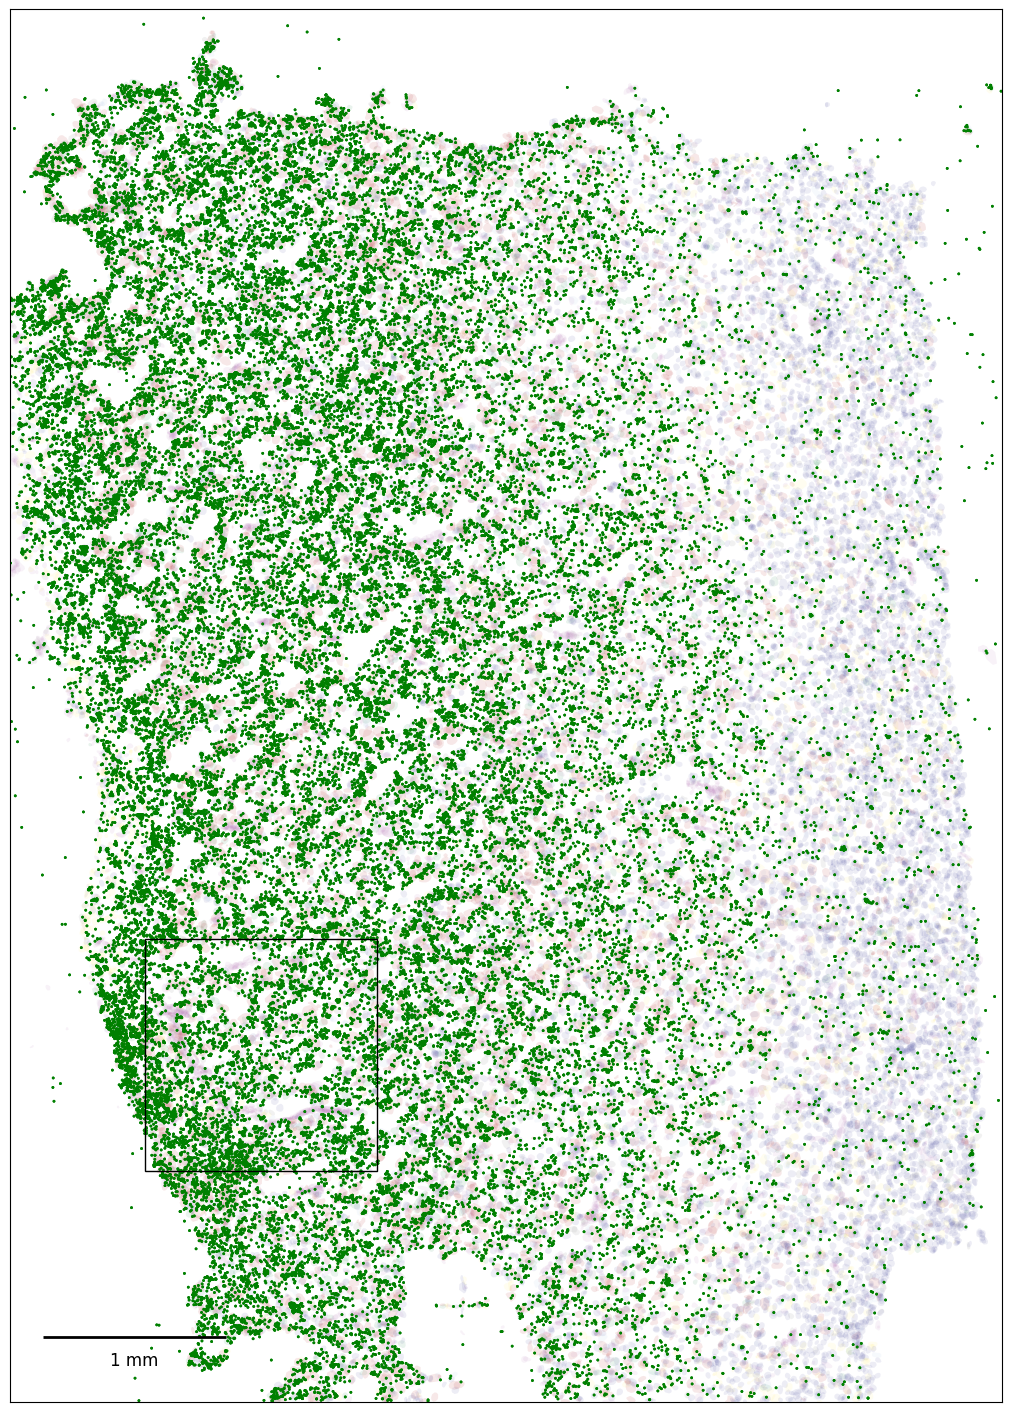

In [7]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

brnum = '5173'
gene = 'CXCL14'
color = 'green'

sdata = get_xenium_sdata(brnum)

fig = sdata.pl.render_shapes("cell_boundaries",
                             color='celltype',
                             groups=['EXC','INH','OLI','OPC','END','AST','MIC'],
                             palette=['#b22222', '#2E8B57', '#5254a3', '#aec7e8', '#bc80bd', '#ffed6f', '#7f7f7f'],
                             scale=5, 
                             outline=False, 
                             fill_alpha=0.1).pl.render_points('transcripts',
                                                              color='feature_name',
                                                              groups=gene,
                                                              palette=color,
                                                              size=1).pl.show(figsize=(10, 20), return_ax=True)

ax = fig
fontprops = fm.FontProperties(size=12)
scalebar = AnchoredSizeBar(ax.transData,
                           size=1000/0.2125,        # x pixels = 1 mm 
                           label='1 mm',
                           loc='lower left',
                           pad=1,
                           borderpad=1,
                           sep=10,
                           frameon=False,
                           color='black',
                           fontproperties=fontprops)
scalebar.size_bar.get_children()[0].set_linewidth(2)
ax.add_artist(scalebar)

rect = patches.Rectangle((3500, 25500), 6000, 6000,  # x, y, width, height
                         linewidth=1,
                         edgecolor='black',
                         facecolor='none')
ax.add_patch(rect)

ax.set_ylim(37457,1500)

plt.legend('', frameon=False)
plt.title('')
plt.xticks([])
plt.yticks([])

plt.savefig('/home/ah2428/palmer_scratch/figs/xenium/ED_fig_5h_ptsd.pdf',bbox_inches='tight',dpi=300)

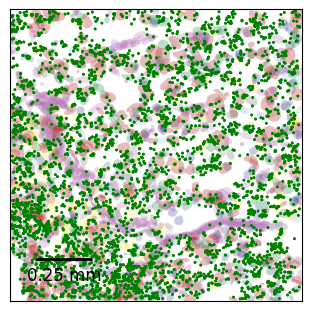

In [8]:
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

crop0 = lambda x: bounding_box_query(
    x,
    min_coordinate=[3500,25500],
    max_coordinate=[9500,31500],
    axes=("x", "y"),
    target_coordinate_system="global",
)
subset = crop0(sdata)

fig = subset.pl.render_shapes("cell_boundaries",
                       color='celltype',
                       groups=['EXC','INH','OLI','OPC','END','AST','MIC'],
                       palette=['#b22222','#2E8B57','#5254a3','#aec7e8','#bc80bd','#ffed6f','#7f7f7f'],
                       scale=5, 
                       outline=False, 
                       fill_alpha=0.3).pl.render_points('transcripts',color='feature_name',groups=gene,palette=color,size=1).pl.show(figsize=(3,3),return_ax=True)

ax = fig
fontprops = fm.FontProperties(size=12)
scalebar = AnchoredSizeBar(ax.transData,
                           size=250/0.2125,        # x pixels = 1 mm 
                           label='0.25 mm',
                           loc='lower left',
                           pad=0.5,
                           borderpad=0.5,
                           sep=5,
                           frameon=False,
                           color='black',
                           fontproperties=fontprops)
scalebar.size_bar.get_children()[0].set_linewidth(2)
ax.add_artist(scalebar)

plt.legend('',frameon=False)
plt.title('')
plt.xticks([])
plt.yticks([])
plt.savefig('/home/ah2428/palmer_scratch/figs/xenium/ED_fig_5h_ptsd_inset.pdf',bbox_inches='tight',dpi=300)